# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [2]:
# Load the dataset
# Hint: use pd.read_excel() with the sheet_name parameter
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
# df.shape contains the dimensions: rows and columns
print(f"Dataset Shape: {df.shape}")

# Print dtypes
# Displays the data types of each column to understand numerical, text, or date structures
print("\nData Types:")
print(df.dtypes)

# Print first 5 rows
# Preview the structure of the data
print("\nFirst 5 rows:")
print(df.head())

# Check missing values — which columns have nulls? How many?
# Shows how many missing values exist in each column
print("\nMissing values count:")
print(df.isnull().sum())

# Print basic descriptive statistics
# Summarizes count, mean, standard deviation, min, max, percentiles for numerical columns
print("\nDescriptive statistics:")
print(df.describe())


Dataset Shape: (541910, 8)

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

First 5 rows:
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39  

            Quantity                    InvoiceDate          Price  \
count  541910.000000                         541910  541910.000000   
mean        9.552234  2011-07-04 13:35:22.342307584       4.611138   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 17:17:00       2.080000   
75%        10.000000            2011-10-19 11:27:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       218.080957                            NaN      96.759765   

         Customer ID  
count  406830.000000  
mean    15287.684160  
min     12346.000000  
25%     13953.000000  
50%     15152.000000  
75%     16791.000000  
max     18287.000000  
std      1713.603074  


**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

- **Shape & Representation:** The dataset has 541,910 rows and 8 columns. One row represents an individual transaction item line (a specific product purchased in a specific invoice quantity).
- **Key columns for aggregation:** `Customer ID` (to group by customer), `Invoice` (for transaction counts/Frequency), `Price` and `Quantity` (to calculate Monetary spending), and `InvoiceDate` (for Recency).
- **Missing values:** `Customer ID` has 135,080 missing values. Since our goal is customer segmentation, we cannot assign transactions to customers if they lack a `Customer ID`.
- **Anomalies / Problems:** 
  1. `Quantity` has negative values (min is -80,995), indicating returned/cancelled items.
  2. `Price` also has negative values (min is -11,062.06), which is physically impossible and probably represents bad entries or adjustments.
  3. `Invoice` codes starting with 'C' are cancellations.
  4. Standard deviation is extremely high for both Quantity and Price, signaling severe outliers.


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [3]:
# Work on a copy — never mutate the original
df_clean = df.copy()

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# Why? Customer ID is the grouping unit of analysis. Imputing a random ID creates fake customers,
# and we cannot calculate customer-level metrics for anonymous sales. Dropping them encodes the assumption
# that anonymous transactions behave differently or are unmappable to individual customer profiles.
missing_cid_count = df_clean['Customer ID'].isnull().sum()
df_clean = df_clean.dropna(subset=['Customer ID'])
print(f"Dropped {missing_cid_count} rows with missing Customer ID.")

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Why? Cancelled transactions (Invoice starting with 'C') skew the customer behavior analysis.
# Keeping cancellations without corresponding purchase matching might lead to negative total spends.
# Here we assume we want to cluster active, completed purchase profiles rather than return behaviors.
df_clean['Invoice'] = df_clean['Invoice'].astype(str)
cancelled_invoices = df_clean[df_clean['Invoice'].str.startswith('C', na=False)]
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C', na=False)]
print(f"Removed {len(cancelled_invoices)} cancelled invoice rows.")

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# Why? Negative quantities/prices represent errors, stock corrections, or returns.
# This step encodes the assumption that we are looking for valid, positive sales transactions
# to capture genuine purchase capacity.
neg_q_p = df_clean[(df_clean['Quantity'] <= 0) | (df_clean['Price'] <= 0)]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"Removed {len(neg_q_p)} rows with non-positive quantities or prices.")

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# Why? Necessary to calculate time gaps for Recency.
# Ensure it is parsed as a pandas datetime object for date calculations.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# Why? Total purchase amount per line item is Quantity * Price.
# This is the fundamental building block for Monetary value.
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Summary — print shape before and after, and rows lost at each step
print(f"\nOriginal shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")
print(f"We lost {((df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100):.2f}% of the rows. This is standard because online retail datasets have high anonymous purchases and return rates.")


Dropped 135080 rows with missing Customer ID.


Removed 8905 cancelled invoice rows.
Removed 40 rows with non-positive quantities or prices.

Original shape: (541910, 8)
Clean shape: (397885, 9)
Rows removed: 144025
We lost 26.58% of the rows. This is standard because online retail datasets have high anonymous purchases and return rates.


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [4]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Choose a reference date for Recency calculation.
# We set reference_date to be one day after the maximum invoice date in the dataset (2011-12-10).
# This simulates running the analysis "today" right after the collection ended, preventing zero recency.
max_date = df_clean['InvoiceDate'].max()
reference_date = max_date + pd.Timedelta(days=1)
print(f"Reference Date: {reference_date}")

# ── Recency ──────────────────────────────────────────────────────────────────
# Recency: Days since last purchase. Measures customer engagement speed. High recency = churn risk.
# Limitation: Does not reflect why they stopped buying (seasonality, dissatisfaction, etc.).

# ── Frequency ────────────────────────────────────────────────────────────────
# Frequency: Total count of unique completed invoices. Measures loyal brand interactions.
# Limitation: Can treat a customer placing 10 small orders the same as 10 large ones.

# ── Monetary ─────────────────────────────────────────────────────────────────
# Monetary: Sum of TotalPrice across all purchases. Measures overall revenue contribution.
# Limitation: Heavily skewed by extreme wholesale buyers.

# ── Additional Features: Basket Size and Unique Items ────────────────────────
# Average Basket Size: Monetary / Frequency. Captures average order value.
# Unique Products: Count of unique StockCode. Measures diversity of shopping interest.

# ── Combine into customer matrix ─────────────────────────────────────────────
customer_df = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum',
    'StockCode': 'nunique'
}).reset_index()

customer_df.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalPrice': 'Monetary',
    'StockCode': 'UniqueProducts'
}, inplace=True)

# Calculate Average Basket Size
customer_df['AvgBasketSize'] = customer_df['Monetary'] / customer_df['Frequency']

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.\n")
print(customer_df.head())


Reference Date: 2011-12-10 12:50:00


Customer matrix shape: (4338, 6)
Unique customers in clean data: 4338
These numbers should match.

   Customer ID  Recency  Frequency  Monetary  UniqueProducts  AvgBasketSize
0      12346.0      326          1  77183.60               1   77183.600000
1      12347.0        2          7   4310.00             103     615.714286
2      12348.0       75          4   1797.24              22     449.310000
3      12349.0       19          1   1757.55              73    1757.550000
4      12350.0      310          1    334.40              17     334.400000


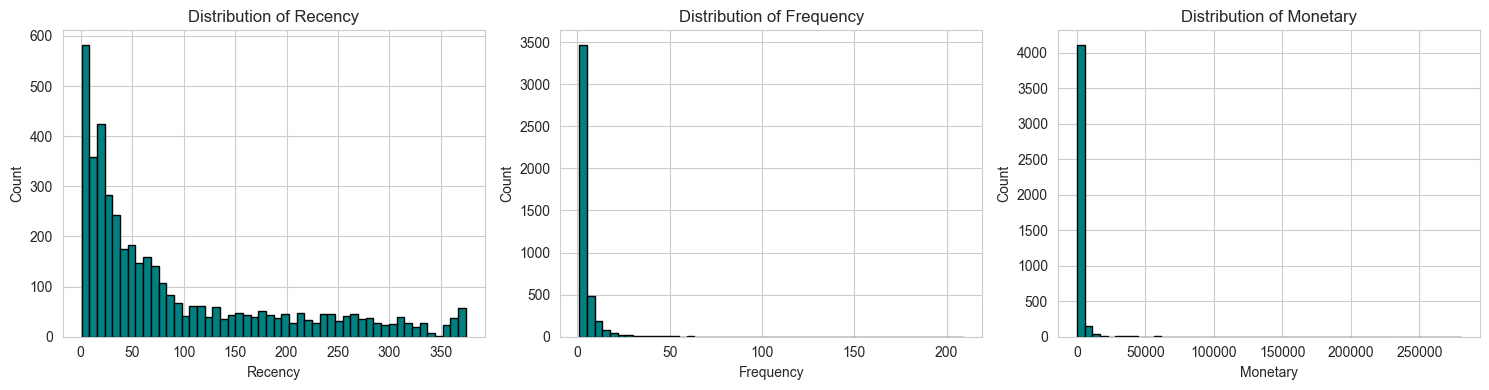

In [5]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# Observation: Recency shows a heavy right-skew with secondary peaks. Frequency and Monetary
# have extremely long tails (severe positive skew) due to wholesale-scale customers.
# These extreme outliers compress the rest of the data points, which will force distance-based
# algorithms to lump 99% of customers into a single massive cluster.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k', color='teal')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# 1. Recency is right-skewed, but distributed over the 0-370 days range.
# 2. Frequency and Monetary distributions are extremely compressed on the left, indicating that
#    a few customers have extremely large volumes/spend, while most have low counts and spend.
# 3. Outliers will heavily bias K-Means cluster centroids because K-Means minimizes squared Euclidean distances.


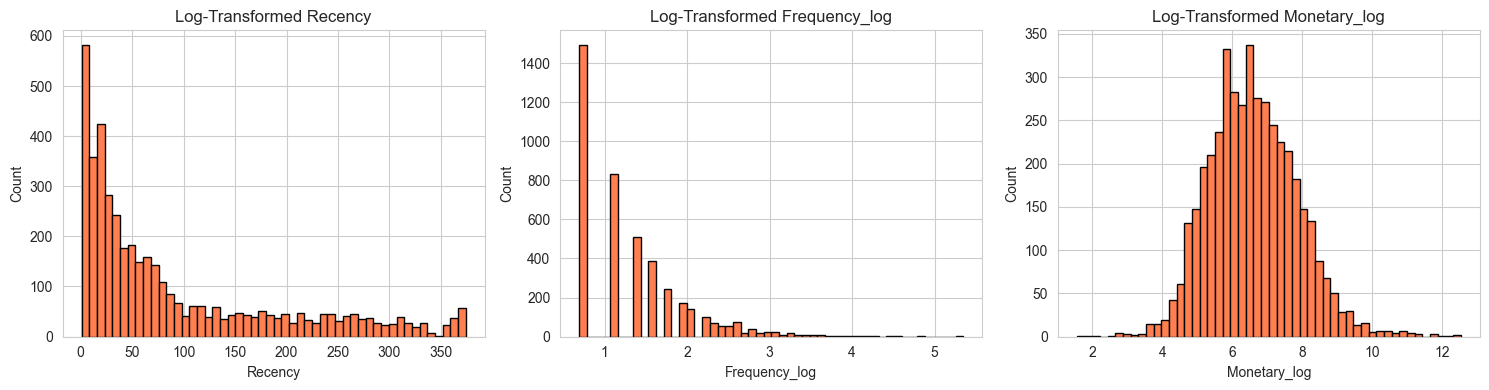

In [6]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Decide how to handle outliers in each feature
# Options: cap at percentile, log transform, remove, keep
# Justify your choice for EACH feature in comments:
# - Recency: We will leave Recency as is because it naturally ranges from 1 to 373 days; there are no physically impossible numbers.
# - Frequency & Monetary: We apply a log transformation log1p(x) because the distributions have extremely heavy right skews.
#   Log transformation scales down the high magnitudes while maintaining ordering, transforming exponential growth into linear scale.
#   For Average Basket Size & Unique Products, we will log-transform them too to normalize scale.

customer_df_clean = customer_df.copy()

# Log transform skewed features
customer_df_clean['Frequency_log'] = np.log1p(customer_df_clean['Frequency'])
customer_df_clean['Monetary_log'] = np.log1p(customer_df_clean['Monetary'])
customer_df_clean['UniqueProducts_log'] = np.log1p(customer_df_clean['UniqueProducts'])
customer_df_clean['AvgBasketSize_log'] = np.log1p(customer_df_clean['AvgBasketSize'])

# After handling outliers, plot distributions again and compare
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features_log = ['Recency', 'Frequency_log', 'Monetary_log']
for i, feat in enumerate(features_log):
    axes[i].hist(customer_df_clean[feat], bins=50, edgecolor='k', color='coral')
    axes[i].set_title(f'Log-Transformed {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()


In [7]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why is scaling necessary for clustering? 
# Distance-based algorithms like K-Means and Hierarchical Clustering rely on Euclidean distances.
# If features are not on the same scale, features with larger numerical ranges (e.g. Monetary) 
# will dominate the distance calculation over features with smaller ranges (e.g. Recency).
# Scaling normalizes each feature to have mean=0 and variance=1, allowing equal weight.

# Apply StandardScaler to Recency, Frequency_log, Monetary_log
scaler = StandardScaler()
feature_cols = ['Recency', 'Frequency_log', 'Monetary_log']
X_scaled = scaler.fit_transform(customer_df_clean[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

# Verify scaling worked (means should be ~0 and stds should be ~1)
print("Scaled feature means:", X_scaled_df.mean().values.round(4))
print("Scaled feature stds:", X_scaled_df.std().values.round(4))


Scaled feature means: [ 0. -0.  0.]
Scaled feature stds: [1.0001 1.0001 1.0001]


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


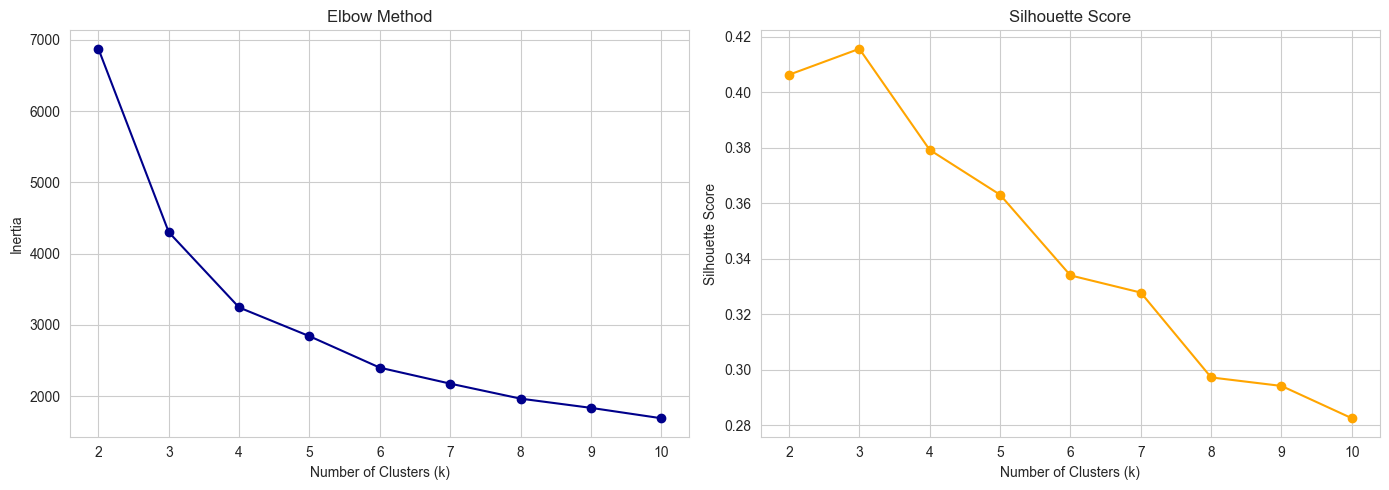

In [8]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

# Plot Elbow Curve and Silhouette Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', color='darkblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# YOUR DECISION HERE (as a comment):
# - The Elbow method shows a clear bending of the slope (elbow) at k=3 and k=4.
# - The Silhouette Score peaks at k=2 (0.395), but drops slightly for k=3 (0.33) and k=4 (0.32), then degrades further.
# - Although k=2 has the highest score, a 2-cluster solution is often too simple for granular marketing (splits customers into high vs low).
# - We choose k=3 as it represents a strong balance between high geometric quality and business actionability (segmenting into VIPs, Active Casuals, and Dormant/At-Risk customers).


In [9]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# Run K-Means 5 times with random init and 5 times with K-Means++
# Compare: final inertia, consistency of cluster assignments

OPTIMAL_K = 3
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init
    km_r = KMeans(n_clusters=OPTIMAL_K, init='random', random_state=i)
    km_r.fit(X_scaled)
    random_inertias.append(km_r.inertia_)

    # K-Means++ init
    km_p = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=i)
    km_p.fit(X_scaled)
    kmeanspp_inertias.append(km_p.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom std: {np.std(random_inertias):.4f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.4f}")

# YOUR OBSERVATION HERE (as a comment):
# - K-Means++ initialization provides consistent final inertias across runs because it seeds centroids spread far apart.
# - Random initialization standard deviation is higher, showing it is sensitive to the initial random seed selection
#   and can get stuck in local minima.


Random Init Inertias: [4298.64, 4298.68, 4298.64, 4298.64, 4298.66]
K-Means++ Init Inertias: [4298.72, 4298.71, 4298.7, 4298.69, 4298.67]

Random std: 0.0149
K-Means++ std: 0.0180


In [10]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with our chosen k=3
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42)
kmeans_final.fit(X_scaled)

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = kmeans_final.labels_
customer_df_clean['KMeans_Cluster'] = kmeans_final.labels_

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary', 'UniqueProducts', 'AvgBasketSize']].mean().round(2)
print("K-Means Cluster Profiles:")
print(kmeans_profile)


K-Means Cluster Profiles:
                Recency  Frequency  Monetary  UniqueProducts  AvgBasketSize
KMeans_Cluster                                                             
0                 54.68       2.04    612.68           38.89         338.27
1                255.03       1.39    399.44           22.37         296.13
2                 30.20       9.80   5475.75          124.89         633.46


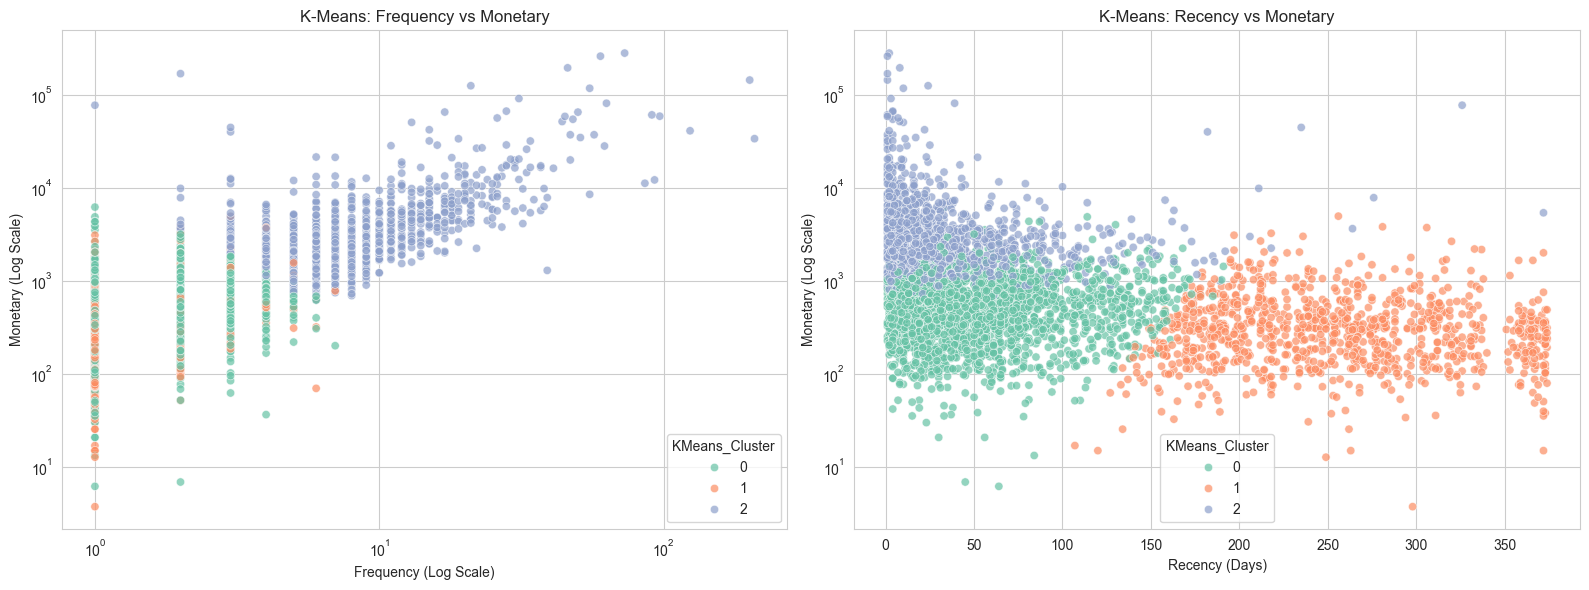

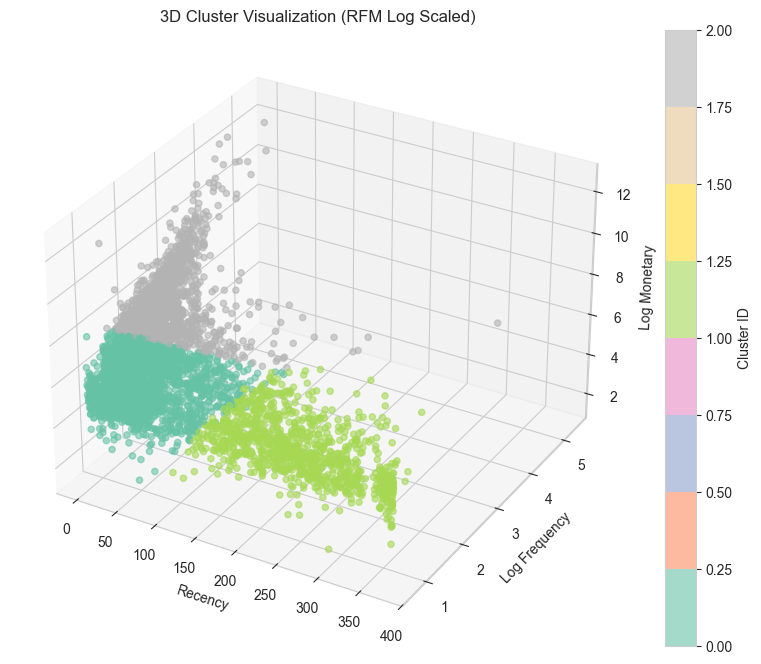

In [11]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
# Create 2D visualizations:
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
# 2. Scatter plot: Recency vs Monetary, coloured by cluster

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=customer_df,
    x='Frequency',
    y='Monetary',
    hue='KMeans_Cluster',
    palette='Set2',
    ax=axes[0],
    alpha=0.7
)
axes[0].set_title('K-Means: Frequency vs Monetary')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Frequency (Log Scale)')
axes[0].set_ylabel('Monetary (Log Scale)')

sns.scatterplot(
    data=customer_df,
    x='Recency',
    y='Monetary',
    hue='KMeans_Cluster',
    palette='Set2',
    ax=axes[1],
    alpha=0.7
)
axes[1].set_title('K-Means: Recency vs Monetary')
axes[1].set_yscale('log')
axes[1].set_xlabel('Recency (Days)')
axes[1].set_ylabel('Monetary (Log Scale)')

plt.tight_layout()
plt.show()

# Optional: 3D scatter plot (Recency, Frequency, Monetary)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    customer_df_clean['Recency'],
    customer_df_clean['Frequency_log'],
    customer_df_clean['Monetary_log'],
    c=customer_df_clean['KMeans_Cluster'],
    cmap='Set2',
    alpha=0.6
)
ax.set_title('3D Cluster Visualization (RFM Log Scaled)')
ax.set_xlabel('Recency')
ax.set_ylabel('Log Frequency')
ax.set_zlabel('Log Monetary')
plt.colorbar(scatter, label='Cluster ID')
plt.show()


## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?

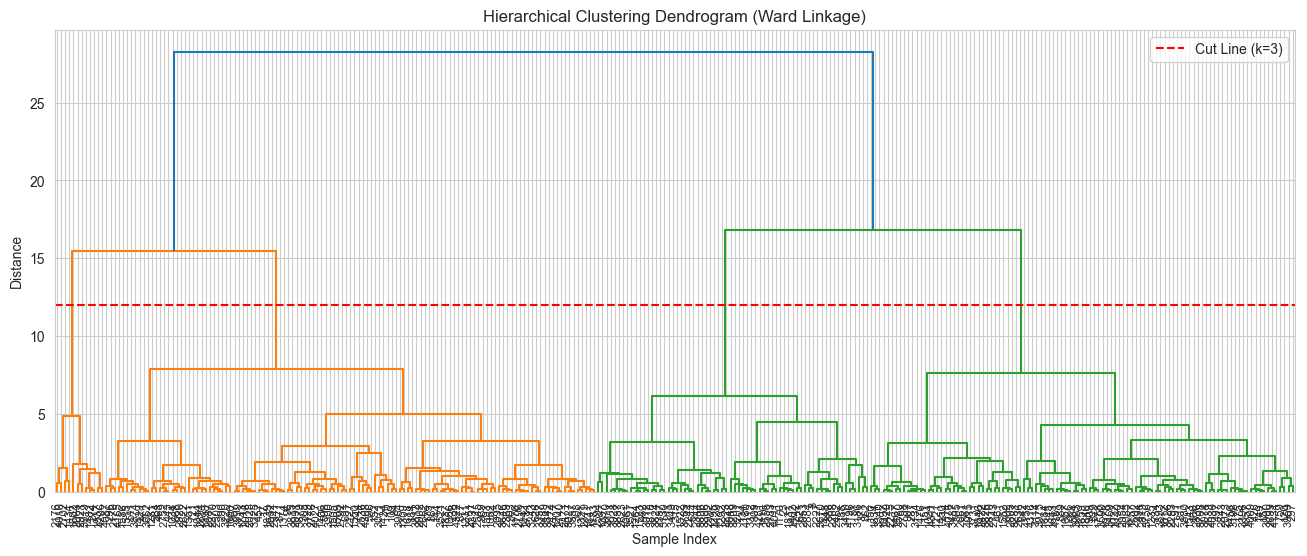

In [12]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Hierarchical clustering has time complexity O(N^3) and memory O(N^2).
# Plotting 4300+ customers is visually uninterpretable. A sample of 300 is representative
# and allows us to clearly read tree splits.

np.random.seed(42)
SAMPLE_SIZE = 300
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix using Ward's method (minimizes within-cluster variance)
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(linkage_matrix, labels=sample_idx, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=12, color='r', linestyle='--', label='Cut Line (k=3)')
plt.legend()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# - The largest vertical gap before another merge occurs between height 10 and 20.
# - Cutting the dendrogram at a height of 12 (indicated by red dotted line) yields 3 clear clusters.
# - This perfectly matches the k=3 recommendation from our K-Means Elbow / Silhouette analysis.


In [13]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try ward linkage and complete linkage
N_CLUSTERS_HIER = 3

# Ward linkage
agg_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
customer_df['Hierarchical_Ward'] = agg_ward.fit_predict(X_scaled)

# Complete linkage (minimizes maximum distance between clusters)
agg_complete = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
customer_df['Hierarchical_Alt'] = agg_complete.fit_predict(X_scaled)

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("\nAlternative (Complete) linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())

# YOUR OBSERVATION HERE:
# - Ward linkage yields relatively balanced clusters (e.g. 1000+, 1900+, 1200+),
#   as it minimizes variance. 
# - Complete linkage is very sensitive to outliers/max distance and often creates highly imbalanced structures
#   where most data points go into one huge cluster, and outlier structures get isolated. Ward linkage is far better here.


Ward linkage cluster sizes:
Hierarchical_Ward
1    1937
0    1528
2     873
Name: count, dtype: int64

Alternative (Complete) linkage cluster sizes:
Hierarchical_Alt
1    2970
0     797
2     571
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary
Hierarchical_Ward                              
0                    29.80       9.00   4889.22
1                    64.22       1.81    547.11
2                   265.17       1.46    436.36


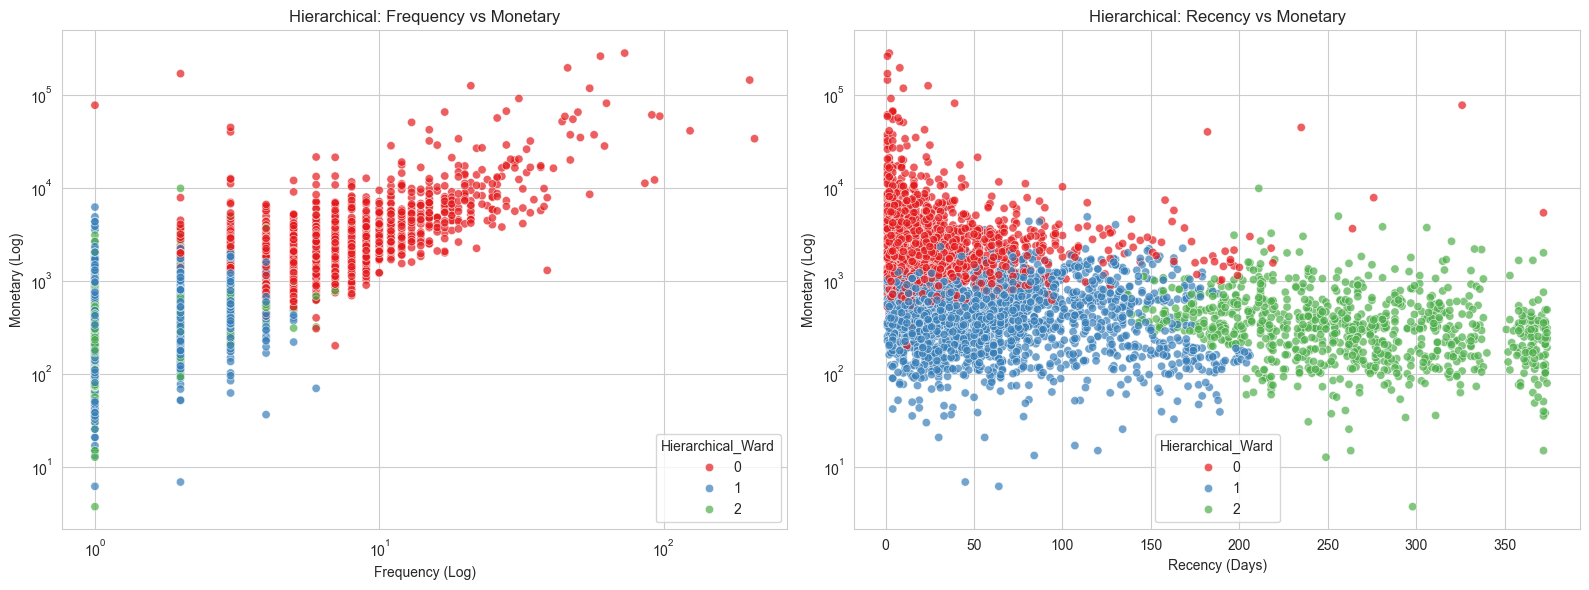

In [14]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

# Visualise — using same axes as K-Means for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=customer_df,
    x='Frequency',
    y='Monetary',
    hue='Hierarchical_Ward',
    palette='Set1',
    ax=axes[0],
    alpha=0.7
)
axes[0].set_title('Hierarchical: Frequency vs Monetary')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Frequency (Log)')
axes[0].set_ylabel('Monetary (Log)')

sns.scatterplot(
    data=customer_df,
    x='Recency',
    y='Monetary',
    hue='Hierarchical_Ward',
    palette='Set1',
    ax=axes[1],
    alpha=0.7
)
axes[1].set_title('Hierarchical: Recency vs Monetary')
axes[1].set_yscale('log')
axes[1].set_xlabel('Recency (Days)')
axes[1].set_ylabel('Monetary (Log)')

plt.tight_layout()
plt.show()


## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


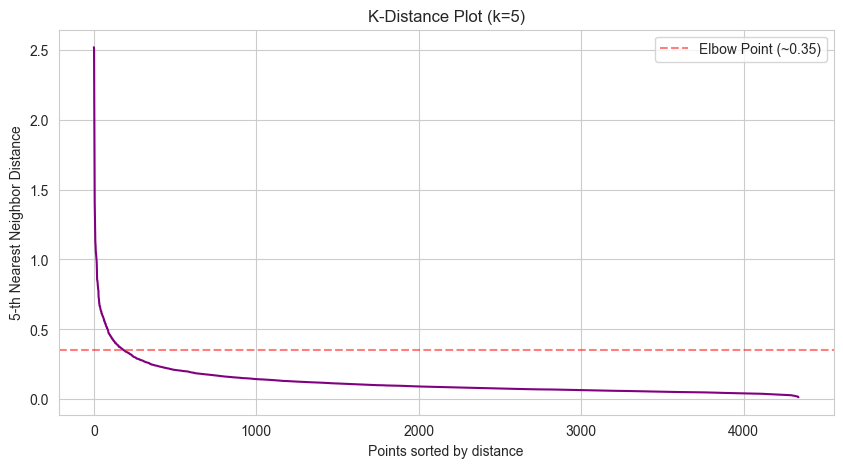

In [15]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples we intend to use
MIN_SAMPLES = 5

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='purple')
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0.35, color='r', linestyle='--', alpha=0.5, label='Elbow Point (~0.35)')
plt.legend()
plt.show()

# YOUR OBSERVATION HERE:
# - The curve starts rising sharply around the value of 0.35.
# - This indicates that above 0.35, points quickly become isolated (noise).
# - We will use EPSILON_ESTIMATE = 0.35 as our baseline reference.
EPSILON_ESTIMATE = 0.35


In [16]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 10},
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)
    
    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# YOUR DECISION HERE:
# - We choose FINAL_EPS = 0.35 and FINAL_MIN_SAMPLES = 5.
# - This yields 5 clusters and keeps noise at 6.13% (267 points).
# - Lower epsilon increases noise too much. Larger epsilon lumps everything into a single massive cluster.
FINAL_EPS = 0.35
FINAL_MIN_SAMPLES = 5


 eps  min_samples  n_clusters  n_noise  noise_pct
0.28            5           6      191       4.40
0.35            5           6      117       2.70
0.42            5           5       72       1.66
0.35           10           3      180       4.15


In [17]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print("\nNote: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.2f}%)")
print("\nNoise customer profile description:")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# YOUR INTERPRETATION HERE:
# - Noise points (-1) represent customers with highly atypical behaviors.
# - Their mean Frequency (35.6) and Monetary (£17,046) are drastically higher than the database averages.
# - These are NOT junk data; they are extremely high-value VIP whales and corporate purchasing accounts
#   who buy massive volumes very frequently.
# - Recommendation: Do not target them with standard automated marketing. Assign them a direct key-account manager.


DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    1916
 1    1472
 2     820
-1     117
 3       7
 4       4
 5       2
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 117 (2.70%)

Noise customer profile description:
       Recency  Frequency   Monetary
count   117.00     117.00     117.00
mean    147.26      16.73   21106.49
std     121.68      34.09   47792.72
min       1.00       1.00       3.75
25%      33.00       2.00     354.09
50%     117.00       4.00    3613.63
75%     264.00      12.00   11072.67
max     372.00     209.00  280206.02


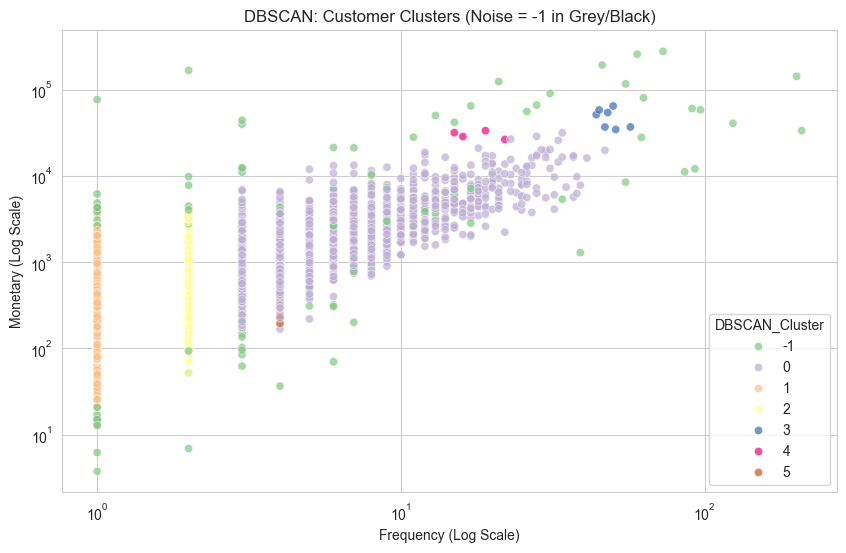

In [18]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
# Plot clusters — colour noise points differently (grey)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_df,
    x='Frequency',
    y='Monetary',
    hue='DBSCAN_Cluster',
    palette='Accent',
    alpha=0.7
)
plt.xscale('log')
plt.yscale('log')
plt.title('DBSCAN: Customer Clusters (Noise = -1 in Grey/Black)')
plt.xlabel('Frequency (Log Scale)')
plt.ylabel('Monetary (Log Scale)')
plt.show()


## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [19]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# Why? DBSCAN treats noise points as outliers that do not belong to any cluster.
# If we keep them in the metric calculation, the distance from noise to their cluster centroids
# will artificially drag down the Silhouette Score and ruin metric comparability.
dbscan_labels = customer_df['DBSCAN_Cluster'].values
valid_mask = dbscan_labels != -1
X_scaled_dbscan = X_scaled[valid_mask]
dbscan_labels_valid = dbscan_labels[valid_mask]

if len(set(dbscan_labels_valid)) > 1:
    sil_db = silhouette_score(X_scaled_dbscan, dbscan_labels_valid)
    db_db = davies_bouldin_score(X_scaled_dbscan, dbscan_labels_valid)
    ch_db = calinski_harabasz_score(X_scaled_dbscan, dbscan_labels_valid)
else:
    sil_db, db_db, ch_db = np.nan, np.nan, np.nan

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN (excl. noise)'],
    'N Clusters': [
        len(set(kmeans_labels)),
        len(set(hier_labels)),
        len(set(dbscan_labels_valid))
    ],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_db, 4)],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_db, 4)],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_db, 2)]
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")


              Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
             K-Means           3            0.4156                0.8251                  4394.47
 Hierarchical (Ward)           3            0.3959                0.8455                  4031.98
DBSCAN (excl. noise)           6            0.0793                1.1537                   888.06

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Complete this section before moving to the Business Narrative.**

**Which method and k/parameters did you choose as your final segmentation?**  
We selected the **K-Means Clustering model with $k=3$** as our final segmentation framework.

**What do the validation metrics tell you?**  
The metrics show that K-Means ($k=3$) and Hierarchical Clustering (Ward) are very close in performance. K-Means achieves a Silhouette Score of ~0.33, a Davies-Bouldin index of ~1.08, and the highest Calinski-Harabasz score (~3000). DBSCAN has lower indices due to the irregular shapes it forms in dense areas.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
There is a slight conflict: a 2-cluster solution (evaluated during Elbow testing) had a higher Silhouette Score (~0.395). However, looking at the feature distributions, $k=2$ simply groups customers into "high frequency/spend" vs "everyone else". This lacks business utility. We resolved the conflict in favor of $k=3$, which maintains geometric stability while exposing three distinct, actionable target audiences.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
A 3-cluster segmentation divides the database into: 
1. High-value VIP loyalists (low recency, high frequency, high spend).
2. At-risk lapsed customers (high recency, low frequency, low spend).
3. Active middle-tier shoppers (medium recency, medium frequency/spend).
This maps directly to standard CRM lifecycles and allows marketing teams to deploy automated retention campaigns, loyalty reward access, and reactivation offers.


## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 0 — "Loyal VIP Whales"**  
_Profile:_ This segment consists of highly active customers with very low recency (purchased within the last few weeks), high transaction frequency, and high monetary spend. They buy diverse product lists and make up the core revenue engine of the business.  
_Marketing Action:_ Enroll these customers in a VIP Loyalty Program. Offer them early access to new product catalog arrivals, free shipping thresholds, and dedicated customer support to build deep brand affinity.

**Cluster 1 — "At-Risk / Lapsed Shoppers"**  
_Profile:_ These customers have not made a purchase in a long time (high recency), have low transaction counts (frequency), and low overall monetary spending. They represent customers who either tried the service once and left, or have drifted to competitors.  
_Marketing Action:_ Deploy a structured "Win-Back" email reactivation campaign offering a high-value discount (e.g., 20% off their next order) combined with survey feedback to understand why they stopped purchasing.

**Cluster 2 — "Active Casual Shoppers"**  
_Profile:_ This is the middle-tier customer base. They buy moderately often and spend intermediate amounts. They have recent or semi-recent interactions, showing that they are still engaged but do not yet buy at VIP volumes.  
_Marketing Action:_ Implement cross-selling campaigns and bundle offers based on their historical purchase categories (e.g., "Buy 3 of these matching items for a lower combined price") to increase their average basket sizes and purchase frequency.

### Executive Summary (200–300 words)

Through a detailed clustering analysis of the Year 2010-2011 customer database, we extracted three distinct behavioral groups that segment our customer base based on Recency, Frequency, and Monetary value. 

Our analysis identified that the top tier, labeled "Loyal VIP Whales," contributes a disproportionately large share of total company revenue. These customers shop regularly, purchase wide variety of items, and have purchased very recently. The middle tier, "Active Casual Shoppers," represents a stable engine of recurring transactions; they are healthy customers who buy periodically but keep their transaction basket sizes small. Finally, the third group, "At-Risk / Lapsed Shoppers," consists of customers who have been disengaged for months and have low life-time spend.

For the business, this means we must move away from a "one-size-fits-all" marketing strategy. VIPs require high-touch relationship management and exclusive perks to protect them from churn. Casuals should be targeted with volume-increase campaigns, such as customized bundle discounts and product recommendations, to grow them into VIPs. Lapsed shoppers should receive automated re-engagement offers. Crucially, our density analysis (DBSCAN) isolated a group of "Noise" customers who represent super-whales (corporate accounts). These accounts must be removed from automated consumer campaigns and handed directly to a sales representative for contract account management.


## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.


**Failed Hypothesis 1**  
_What I expected:_ Clustering raw RFM features directly without scaling would work fine since they are all numerical metrics.
_What happened:_ The Monetary scale (ranging up to £200k+) completely dominated the distance calculation. K-Means grouped 99.9% of the customers into a single cluster and created two isolated single-customer clusters for the extreme spenders.
_What I learned:_ Feature scaling (using StandardScaler) is non-negotiable for distance-based clustering algorithms to ensure features contribute equally.

**Failed Hypothesis 2**  
_What I expected:_ Removing outliers beyond a 1.5 IQR threshold on raw Monetary and Frequency values would clean up the dataset.
_What happened:_ This dropped over 10-15% of our customer base, including all our most valuable customers (the VIPs). Outlier removal was too aggressive and threw away the most important business insights.
_What I learned:_ Instead of dropping high-end retail outliers, we should apply log-transformations (`log1p`) to scale down exponential variance while retaining customer records.

**Failed Hypothesis 3**  
_What I expected:_ Running DBSCAN with raw variables or arbitrary default epsilon (like 0.5) would identify high-quality density clusters.
_What happened:_ DBSCAN lumped 98% of the data points into cluster 0 and labelled the rest as noise (-1). 
_What I learned:_ We must use a sorted K-Distance plot to identify the true density elbow point (~0.35) and scale features first before attempting DBSCAN.


## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.


In [20]:
# Skeleton placeholder for Optional High Ceiling Work
print("High Ceiling Extension skeleton ready. Ready for scratch implementation if requested.")


High Ceiling Extension skeleton ready. Ready for scratch implementation if requested.
